<center><h1><b>How Do the Games’ Genres, their Sales and User and Critics Score, and Series, Focus of the games connected with the Game's Global Sales</b></h1></center>

<br><br>

<center><h3>Angelina Podolako s1125886, Feliks Lysiuk s1125187</h3></center>

<center><h4>Radboud University</h4></center>

<center><h4>Frequentist Statistics</h4></center>

<center><h4>June 2024</h4></center>

##Abstract
This study carried out to find the association between  the influence of factors such as the genre of the game, the evaluation of the game by users, the critics' evaluation, is game a part of a series of games, what is the main focus of the game on their expected global sales. A multiple regression model has been constructed to address this problem. In the course of the work, it turned out that user score, critics score and series are significant predictors of global sales. Ultimately, the constructed model can be used as a tool for forecasting sales of games on the global market.

## Introduction

Currently, there are many games of various genres, and this list is constantly being updated. Each genre demonstrates a completely different gameplay, requires different skills and abilities. There are many explanations why certain games are liked by different groups of society, with different interests, different genders and ages. Of course, this gives reason to believe that the genre can predict the success of this game.\
Moreover, critical or user ratings can be important aspects for predicting the level of global sales of games. Critics often give ratings before the start of game sales, which affects the very first impression of users who have not tried the gameplay yet, but have already heard about this game. However, given that not everyone is ready to trust critics, the evaluation of users is also important.\
If the game is a series of games, then it may seem that sales success will be higher due to recognition, which we found out in our work. And it was also important to find out which type of game would bring more success to developers based on gameplay or narrative.

In this work, we are trying to figure out and give an accurate answer to the following question: "Does the genre of the game, the evaluation of users, the evaluation of critics, the factor of whether the game is a series of games, and what is the focus of the game, on its sales and evaluation by users and experts? And if so, to what extent?". To answer this question, a multiple linear regression model based on data from the Tagged-Data-Final.csv dataset was used.
The task of this study is to find a dependency, if any, so that game creators and publishers can have information about its sales before choosing a game genre. This can help companies and people involved in game development to improve the quality of their work.

The dependent variables are User_Score, Critics_Score, Genre, StoryFocus or GameplayFocus, Series.

The fitted multiple linear regression model explains which of these variables are related and affect global game sales. More details regarding the model can be found in the results, and their meaning is discussed in the conclusion. The model that has been constructed is limited by the time the data was collected.

###Hypotheses
**Null Hypothesis (Ho)**:
The variables (User_Score, Critics_Score, Genre, StoryFocus or GameplayFocus, Series) do not affect the sales or user and expert evaluation of games.\
**H0:** βUser_Score ​= βCritics_Score ​= βGenre​ = βStoryFocus or GameplayFocus ​= βSeries ​= 0

**Alternative Hypothesis (Ha):**
The variables (User_Score, Critics_Score, Genre, StoryFocus or GameplayFocus, Series) affect the sales or user and expert evaluation of games.\
**Ha:** βUser_Score ​= βCritics_Score ​= βGenre​ = βStoryFocus or GameplayFocus ​= βSeries ≠ 0

##Data
A very suitable dataset was found in the file *Tagged-Data-Final.csv*, which was uploaded by the user *The Devastator* on [kaggle.com](https://).

The original (raw) dataset consists of 11563 data lines representing 16 columns, and the final dataset consists of 4424 data lines, representing 16 columns.
It collected data about games’ sales, genre, publisher, platform, rating, story focus and gameplay focus for each game by 2016.

The DataFrame **games** contains data on 6894 games with 18 variables (columns):

- *Name*: Name of the game
- *Year_of_Release*: Year of release
- *Genre*: The genre of the game
- *Publisher*: Publisher of the game
- *NA_Sales*: Sales in North America (in millions of copies)
- *EU_Sales*: Sales in Europe (in millions of copies)
- *JP_Sales*: Sales in Japan (in millions of copies)
- *Other_Sales*: Sales in other regions (in millions of copies)
- *Global_Sales*: Global sales (in millions of copies)
- *Critic_Score*: Average critics score (on a 100-point scale)
- *Critic_Count*: The number of critics' ratings
- *User_Score*: Average user rating (on a 10-point scale)
- *User_Count*: The number of user ratings
- *Developer*: Game Developer
- *Rating*: Age rating of the game
- *StoryFocus*: Does the game focus on the plot (values 'x' = [YES] or NaN = [NO])
- *Gameplay Focus*: Does the game focus on gameplay (values 'x' = [YES] or NaN = [NO])
- *Series*: Is the game part of a series (values 'x' = [YES] or NaN = [NO])

###Population
People who play games, being calculated as split to the regions they lived in 2016, and globally at the same time.
You can generalize the answers to all the people who play games. For greater reliability, in the future, it is advised to re-analyze (starting with data collection) to ensure that the data does not lose its relevance over time.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, probplot

import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np

sns.set_style("whitegrid")

In [2]:
# needed/convenient only  if you're working in Google colab (not for local Jupyter)
from google.colab import files
uploaded = files.upload()

Saving Tagged-Data-Final.csv to Tagged-Data-Final.csv


In [3]:
games = pd.read_csv("Tagged-Data-Final.csv")
games

,Name,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,Story Focus,Gameplay Focus,Series
0,.hack//Infection Part 1,2002.0,Role-Playing,Atari,0.49,0.38,0.26,0.13,1.27,75.0,35.0,8.5,60.0,CyberConnect2,T,x,NaN,x
1,.hack//Mutation Part 2,2002.0,Role-Playing,Atari,0.23,0.18,0.20,0.06,0.68,76.0,24.0,8.9,81.0,CyberConnect2,T,x,NaN,x
2,.hack//Outbreak Part 3,2002.0,Role-Playing,Atari,0.14,0.11,0.17,0.04,0.46,70.0,23.0,8.7,19.0,CyberConnect2,T,x,NaN,x
3,[Prototype],2009.0,Action,Activision,0.84,0.35,0.00,0.12,1.31,78.0,83.0,7.8,356.0,Radical Entertainment,M,NaN,x,x
4,[Prototype],2009.0,Action,Activision,0.65,0.40,0.00,0.19,1.24,79.0,53.0,7.7,308.0,Radical Entertainment,M,NaN,x,x
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6889,Zubo,2008.0,Misc,Electronic Arts,0.08,0.02,0.00,0.01,0.11,75.0,19.0,7.6,75.0,EA Bright Light,E10+,NaN,x,NaN
6890,Zumba Fitness,2010.0,Sports,505 Games,1.74,0.45,0.00,0.18,2.37,42.0,10.0,5.5,16.0,"Pipeworks Software, Inc.",E,NaN,x,NaN
6891,Zumba Fitness: World Party,2013.0,Misc,Majesco Entertainment,0.17,0.05,0.00,0.02,0.24,73.0,5.0,6.2,40.0,Zoe Mode,E,NaN,x,NaN
6892,Zumba Fitness Core,2012.0,Misc,505 Games,0.00,0.05,0.00,0.00,0.05,77.0,6.0,6.7,6.0,Zoe Mode,E10+,NaN,x,NaN


###The response variable
1.   *Global Sales* – The sales of the game in the world,

###Explanatory variables

1.   *User_Score* - Average score given by users to the game, given as a float
2.   *Critics_Score* - Average score given by critics to the game, given as a float
3.   *Genre* - Genre the game belongs to, given as a String
4.   *Story Focus* - Does the game focuses on story , values - 'x' = **[YES]** or NaN = **[NO]**

  *Important note: (in the code was changed to the [Story_Focus] to be int(1 for Yes, 0 for No))  
  (Mutually exclusive with [Gameplay Focus] and its' representations )*
5.   *Gameplay Focus* - Does the game focuses on gameplay , values - 'x' = **[YES]** or NaN = **[NO]**

  *Important note: (in the code was changed to the [Gameplay_Focus] to be int(1 for Yes, 0 for No))
  (Mutually exclusive with [Story Focus] and its' representations )*
6.   *Series* - Is the game part of the series or it is independent, values - 'x' = **[YES]** or NaN = **[NO]**

  *Important note: (In the code was changed to be int(1 for Yes, 0 for No))*


##Model

###Data preprocessing

In [4]:
# Handle missing values in relevant columns
games.dropna(subset=['Global_Sales', 'Critic_Score', 'User_Score'], inplace=True)

# Convert 'Series', 'Story Focus', 'Gameplay Focus' columns to the int values
games['Series'] = games['Series'].apply(lambda x: 1 if pd.notna(x) and x == 'x' else 0)
games['Story Focus'] = games['Story Focus'].apply(lambda x: 1 if pd.notna(x) and x == 'x' else 0)
games['Gameplay Focus'] = games['Gameplay Focus'].apply(lambda x: 1 if pd.notna(x) and x == 'x' else 0)

# Rename columns to avoid spaces and future problems
games.rename(columns={'Story Focus': 'Story_Focus', 'Gameplay Focus': 'Gameplay_Focus'}, inplace=True)

# Encode 'Genre' as dummy variables
games_encoded = pd.get_dummies(games, columns=['Genre'], drop_first=True)

games_encoded.columns = games_encoded.columns.str.replace(' ', '_').str.replace('-', '_')

games_encoded #show data

,Name,Year_of_Release,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,...,Genre_Fighting,Genre_Misc,Genre_Platform,Genre_Puzzle,Genre_Racing,Genre_Role_Playing,Genre_Shooter,Genre_Simulation,Genre_Sports,Genre_Strategy
0,.hack//Infection Part 1,2002.0,Atari,0.49,0.38,0.26,0.13,1.27,75.0,35.0,...,False,False,False,False,False,True,False,False,False,False
1,.hack//Mutation Part 2,2002.0,Atari,0.23,0.18,0.20,0.06,0.68,76.0,24.0,...,False,False,False,False,False,True,False,False,False,False
2,.hack//Outbreak Part 3,2002.0,Atari,0.14,0.11,0.17,0.04,0.46,70.0,23.0,...,False,False,False,False,False,True,False,False,False,False
3,[Prototype],2009.0,Activision,0.84,0.35,0.00,0.12,1.31,78.0,83.0,...,False,False,False,False,False,False,False,False,False,False
4,[Prototype],2009.0,Activision,0.65,0.40,0.00,0.19,1.24,79.0,53.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6889,Zubo,2008.0,Electronic Arts,0.08,0.02,0.00,0.01,0.11,75.0,19.0,...,False,True,False,False,False,False,False,False,False,False
6890,Zumba Fitness,2010.0,505 Games,1.74,0.45,0.00,0.18,2.37,42.0,10.0,...,False,False,False,False,False,False,False,False,True,False
6891,Zumba Fitness: World Party,2013.0,Majesco Entertainment,0.17,0.05,0.00,0.02,0.24,73.0,5.0,...,False,True,False,False,False,False,False,False,False,False
6892,Zumba Fitness Core,2012.0,505 Games,0.00,0.05,0.00,0.00,0.05,77.0,6.0,...,False,True,False,False,False,False,False,False,False,False


To start with, we had to remove the records that do not contain any values under the Global_Sales, Critic_Score and User_Score columns. This step is essential as it ensures the precision of our analysis by only considering complete data. Missing values can distort the results of the analysis and lead to incorrect conclusions.\
We will also convert categorical data into numeric data. The Series, Story Focus and Gameplay Focus columns contain the values 'x' for "Yes" and NaN for "No". We replace 'x' with 1 and NaN with 0 to simplify their use in the regression model, since regression models require numeric inputs.\
The column names were altered from Story Focus and Gameplay Focus to Story_Focus and Gameplay_Focus. This change was made with a view to ensuring smooth analysis and coding processes— having spaces in column names might lead to issues in error detection.\
In the end, we will convert the categorical variable Genre into dummy variables. In simple terms, this action involves generating an individual column for every genre, with binary values: 0 or 1. Here, '1' denotes membership to that genre. Furthermore, by setting drop_first=True, we eliminate the initial genre column from our dataset in order to prevent multicollinearity.

###Multiple linear regression model

In [5]:
print(stats.ttest_ind(games['Global_Sales'], games['Critic_Score']))
print(stats.ttest_ind(games['Global_Sales'], games['User_Score']))
print(stats.ttest_ind(games['Global_Sales'], games['Series']))
print(stats.ttest_ind(games['Global_Sales'], games['Story_Focus']))
print(stats.ttest_ind(games['Global_Sales'], games['Gameplay_Focus' ]))

TtestResult(statistic=-412.15987253315325, pvalue=0.0, df=13786.0)
TtestResult(statistic=-219.31933301974675, pvalue=0.0, df=13786.0)
TtestResult(statistic=27.532136936041034, pvalue=1.7276650949912798e-162, df=13786.0)
TtestResult(statistic=27.68759123823802, pvalue=2.943050054767639e-164, df=13786.0)
TtestResult(statistic=-7.765289366903133, pvalue=8.718325447259215e-15, df=13786.0)


In [6]:
# Assuming 'games_encoded' is your dataset with Global_Sales and other variables
formula = 'Global_Sales ~ Critic_Score + User_Score + Series + '
formula += ' + '.join([f'{col}' for col in games_encoded.columns if col.startswith('Genre_') and col != 'Genre_Sports' and col != 'Genre_Puzzle' and col != 'Genre_Simulation' and col != 'Genre_Fighting' and col != 'Genre_Racing' and col != 'Genre_Shooter' and col != 'Genre_Platform'])
# Genre_Sports, Gameplay_Focus, Genre_Puzzle, Genre_Simulation, Genre_Fighting, Story_Focus, Genre_Racing, Genre_Shooter, Genre_Platform
# Fit the initial model
final_model = ols(formula, data=games_encoded).fit()

# Print initial model summary
print("Final Model Summary:")
print(final_model.summary())


Final Model Summary:
                            OLS Regression Results                            
Dep. Variable:           Global_Sales   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     74.14
Date:                Fri, 21 Jun 2024   Prob (F-statistic):          6.11e-104
Time:                        13:46:38   Log-Likelihood:                -14152.
No. Observations:                6894   AIC:                         2.832e+04
Df Residuals:                    6886   BIC:                         2.837e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

We used a multiple linear regression model where Global_Sales is a dependent variable (which we are trying to predict) and Critic_Score, User_Score, Genre, Series, Story_Focus and Gameplay_Focus are independent variables (factors that can affect sales). These factors were chosen to test the hypothesis that critical and user ratings, game genre, series affiliation, and focus on gameplay or storytelling can influence global sales of the game.

Using the OLS method, we find a linear relationship between a dependent variable and several independent variables.

That's what the output gives us:\
R-squared (R^2): A low R-squared value indicates that there are many other factors that can affect sales, and they are not included in this model.The R-squared value: 0.070 shows that about 7% of the variation in global sales is explained by this model. This indicates that the model explains a small part of the variation in the data.

Coefficients and their significance: Critics' ratings and belonging to the series have a significant positive impact on game sales, while user ratings have a negative impact. The lack of significance of the focus on narrative or gameplay may indicate that these factors are not decisive for global sales.

Critic_Score: A coefficient of 0.0381 (p-value = 0.000) indicates a positive and significant impact of critics' ratings on sales. \
User_Score: A coefficient of -0.0890 (p-value = 0.000) indicates a negative and significant impact of user ratings on sales. \
Series: A coefficient of 0.3099 (p-value = 0.000) indicates a positive and significant impact of belonging to the series on sales. \
Story_Focus and Gameplay_Focus: These variables do not have a significant impact on sales, since their p-value is > 0.05.    
##Genres:  
Adventure: A coefficient of -0.3435 (p-value = 0.000) indicates a negative and significant impact of on sales in case game is developed in it.\
Fighting:  This variable does not have a significant impact on sales, since its p-value is > 0.05.\
Platform:  This variable does not have a significant impact on sales, since its p-value is > 0.05.\
Puzzle:  This variable does not have a significant impact on sales, since its p-value is > 0.05.\
Racing:  This variable does not have a significant impact on sales, since its p-value is > 0.05. \
Role-Playing:  A coefficient of -0.1985 (p-value = 0.009) indicates a negative and significant impact of on sales in case game is developed in it.\
Shooter:  This variable does not have a significant impact on sales, since its p-value is > 0.05.\
Simulation:  This variable does not have a significant impact on sales, since its p-value is > 0.05.\
Sports:  This variable does not have a significant impact on sales, since its p-value is > 0.05.\
Strategy:  A coefficient of -0.6227 (p-value = 0.000) indicates a negative and significant impact of on sales in case game is developed in it.\
Misc: A coefficient of 0.3835 (p-value = 0.000) indicates a positive and significant impact of on sales in case game is developed in it.

In [7]:
# Correlation

correlation_results = {}
for genre in games['Genre'].unique():
    genre_data = games[games['Genre'] == genre]
    correlation = genre_data[['Global_Sales', 'Critic_Score', 'User_Score']].corr()
    correlation_results[genre] = correlation
    print(f"Correlation for {genre}:\n", correlation)

# One-way ANOVA tests to check the mean difference


anova_sales = f_oneway(*(games[games['Genre'] == genre]['Global_Sales'] for genre in games['Genre'].unique()))
print("ANOVA result for Global Sales by Genre:\n", anova_sales)

anova_critic = f_oneway(*(games[games['Genre'] == genre]['Critic_Score'] for genre in games['Genre'].unique()))
print("ANOVA result for Critic Score by Genre:\n", anova_critic)

anova_user = f_oneway(*(games[games['Genre'] == genre]['User_Score'] for genre in games['Genre'].unique()))
print("ANOVA result for User Score by Genre:\n", anova_user)

Correlation for Role-Playing:
               Global_Sales  Critic_Score  User_Score
Global_Sales      1.000000      0.405149    0.125246
Critic_Score      0.405149      1.000000    0.501374
User_Score        0.125246      0.501374    1.000000
Correlation for Action:
               Global_Sales  Critic_Score  User_Score
Global_Sales      1.000000      0.389324    0.193611
Critic_Score      0.389324      1.000000    0.606865
User_Score        0.193611      0.606865    1.000000
Correlation for Racing:
               Global_Sales  Critic_Score  User_Score
Global_Sales      1.000000      0.245305    0.166397
Critic_Score      0.245305      1.000000    0.556247
User_Score        0.166397      0.556247    1.000000
Correlation for Misc:
               Global_Sales  Critic_Score  User_Score
Global_Sales      1.000000      0.083161    0.076134
Critic_Score      0.083161      1.000000    0.612323
User_Score        0.076134      0.612323    1.000000
Correlation for Adventure:
               Global

As a result, we analyze the relationship between global sales, critics' ratings and user ratings in the context of various genres. Correlation analysis was used to find out how strongly sales and ratings of critics and user ratings are related. This helps to understand what factors can influence sales within each genre. ANOVA tests are used to check for significant differences in sales and ratings between different genres. We used it to determine whether genres affect ratings and sales, and how significant these differences are. That is, this analysis helps to draw conclusions about which genres are more successful in terms of sales and which factors influence the success of the game, depending on the genre.

For each genre, we get a correlation matrix showing how strongly global sales, critical ratings, and user ratings are related. A value of 1.000000 in the diagonal means an ideal correlation of the variable with itself. A value of 0.405149 indicates a moderate positive correlation between global sales and critical ratings. A value of 0.125246 indicates a weak positive correlation between global sales and user ratings.

Global Sales by Genre: A p value (6.875756411503829e-09) indicates that there is a statistically significant difference in global sales between different genres \
Critical Score by Genre: A p value (1.0070205794080673e-36) indicates that there is a statistically significant difference in critics' ratings between different genres.\
User Score by Genre: The p value (1.7150189045564263e-19) indicates that there is a statistically significant difference in user ratings between different genres.

Text(0.5, 1.0, 'Distribution of Global Sales')

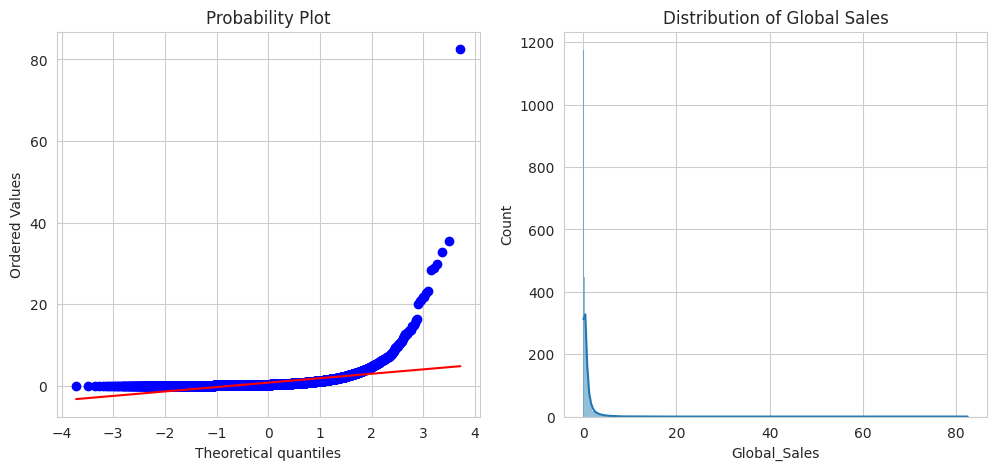

In [8]:
# Distribution of Global Sales
fig,ax =  plt.subplots(1,2, figsize=(12,5))

stats.probplot(games['Global_Sales'], dist='norm', plot=ax[0])
plt.title('Probability Plot of Global Sales')
sns.histplot(games['Global_Sales'], kde=True)
plt.title('Distribution of Global Sales')



###Data visualization

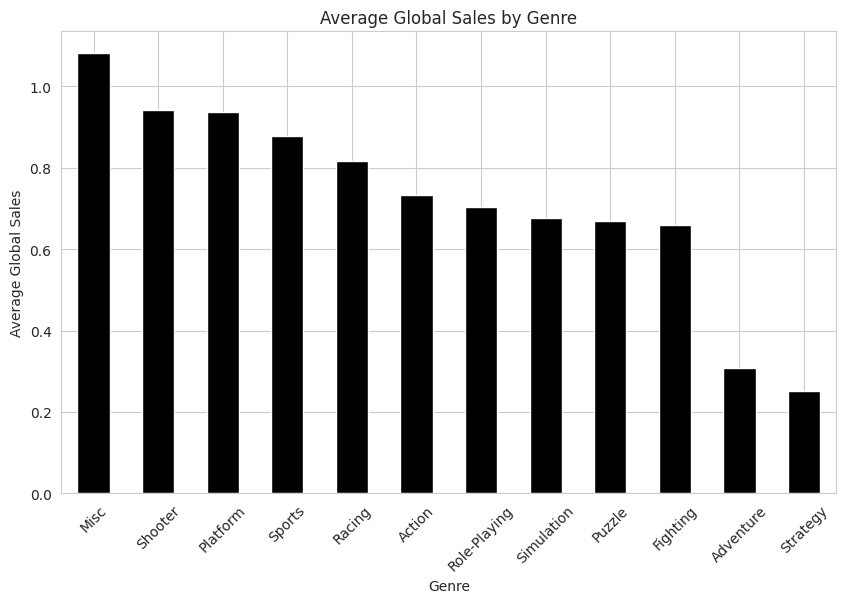

In [9]:
# Calculate mean global sales for each genre
mean_sales_by_genre = games.groupby('Genre')['Global_Sales'].mean()

# Bar plot for global sales by genre
plt.figure(figsize=(10, 6))
mean_sales_by_genre.sort_values(ascending=False).plot(kind='bar', color='black')
plt.title('Average Global Sales by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Global Sales')
plt.xticks(rotation=45)
plt.show()

Next we'll look at the sales figures, for each genre shedding light on which genres tend to perform better overall. We've crafted a bar graph to visually represent the sales of games across different genres. To present this data effectively we've filtered it by genre computed the sales numbers for each genre and arranged them in descending order. This visual representation helps us identify which genres generally have sales figures providing insights into what factors contribute to the success of games.
Upon inspection it's evident that in the coming months new game releases are predicted to achieve a level of 0.14. Following that you can explore genres like shooters, RPGs (role playing games) racing titles, platformers, miscellaneous games, fighting games, simulators, strategies and adventures. Later in our discussion is a puzzle game, with graphics expected for release in 0.02 years.


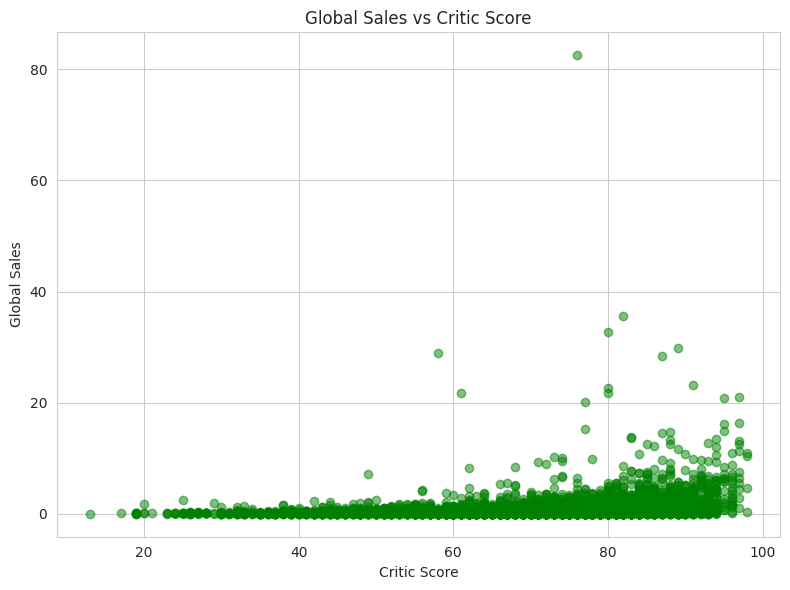

In [10]:
# Scatter plot [Global Sales vs Critic Score]
plt.figure(figsize=(8, 6))
plt.scatter(games_encoded['Critic_Score'], games_encoded['Global_Sales'], alpha=0.5, color='green')
plt.title('Global Sales vs Critic Score')
plt.xlabel('Critic Score')
plt.ylabel('Global Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

We created a scatter chart to visualize the relationship between global game sales and critical acclaim. The chart shows critical ratings on the X—axis, and global sales on the Y-axis. Thanks to the graph, we will see if there is a relationship between these variables.

The scatter plot shows the dependence of global game sales on critics' ratings. It can be seen that there is a positive correlation between these variables, that is, the higher the critics' score, the higher the global sales.

Before the estimates of 20, global sales were at 0 and after that they gradually increase. Reaching the mark of 100 according to critics, global sales clearly reach the level of 15 and vary by 15-35, moreover, there is an outlier, but only 1.

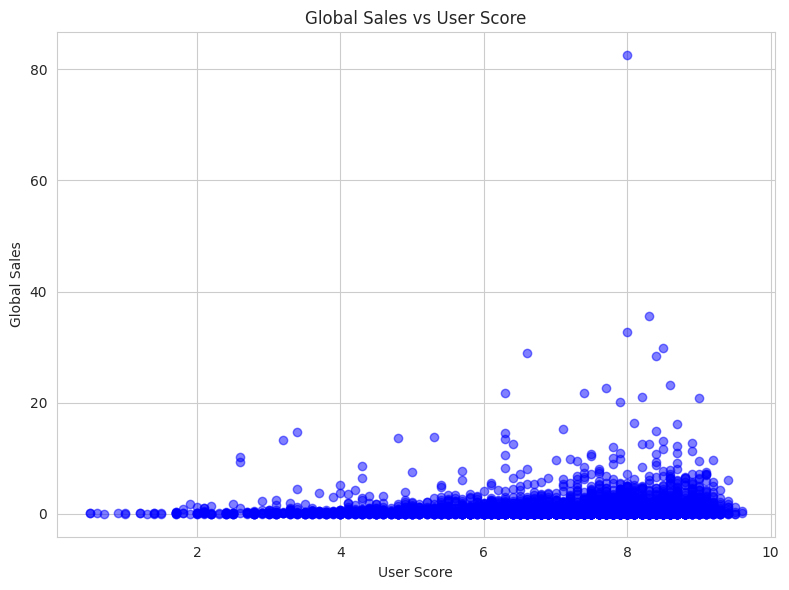

In [11]:
# Scatter plot [Global Sales vs User Score]
plt.figure(figsize=(8, 6))
plt.scatter(games_encoded['User_Score'], games_encoded['Global_Sales'], alpha=0.5, color='blue')
plt.title('Global Sales vs User Score')
plt.xlabel('User Score')
plt.ylabel('Global Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

We created a scatter chart to visualize the relationship between global game sales and user ratings. The graph on the X—axis has user ratings, and on the Y-axis there are global sales. This way we can find out if there is a relationship between these variables.

This graph shows how global game sales are related to user ratings. The points on the graph are located at level 0 on the X axis and begin to rise with increasing user ratings. At the rating level of 9 on the X axis, the points are at the global sales level of about 10. There are also less frequent points on the chart, varying at the global sales level of 10-30, and one outlier located far and high from the main mass of points.

In [12]:
# Doing regression analysis for each genre
regression_results = {}
for genre in games['Genre'].unique():
    genre_data = games[games['Genre'] == genre]
    if len(genre_data) > 1:  # Ensure there's enough data for regression
        model = ols('Global_Sales ~ Critic_Score + User_Score', data=genre_data).fit()
        regression_results[genre] = model.summary()
        print(f"Regression analysis for {genre}:\n", model.summary())

Regression analysis for Role-Playing:
                             OLS Regression Results                            
Dep. Variable:           Global_Sales   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     74.08
Date:                Fri, 21 Jun 2024   Prob (F-statistic):           5.92e-30
Time:                        13:46:50   Log-Likelihood:                -1095.3
No. Observations:                 715   AIC:                             2197.
Df Residuals:                     712   BIC:                             2210.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept

The last step of the analysis involves performing regression analysis, for each type of video game genre in the dataset. Specifically the analyst creates regression models to forecast sales based on both user ratings within each genre.

These findings illustrate how the ratings from critics and users impact the sales of games across genres. This insight helps determine whether critics reviews or user feedback has a influence on game sales, within various genres. By understanding the significance of ratings companies can prioritize enhancing aspects of games that matter most to either critics or users depending on the genre. This enables developers to target elements of games effectively to drive sales.

In most genres, critics' ratings have a significant positive impact on global sales. For example, in the Shooter genre, the Critic_Score coefficient = 0.0696 (p < 0.000), which indicates a high significant impact.\
The impact of user ratings is less clear. In some genres, such as Role-Playing, this influence is even negative (User_Score coefficient = -0.1183, p = 0.008).\
The significance and impact of ratings vary by genre, which may reflect differences in audience and critics' expectations for different types of games.

###Additional analysis
After fitting a model, the following assumptions should not be violated:
1. Variability of the residuals is nearly constant.
2. Residuals of the model are nearly normal.
3. Residuals are independent
4. Each variable is linearly related to the outcome.

To ensure the assumptions are met, scatterplots,histograms and QQ plots are used to validate the variables selected.

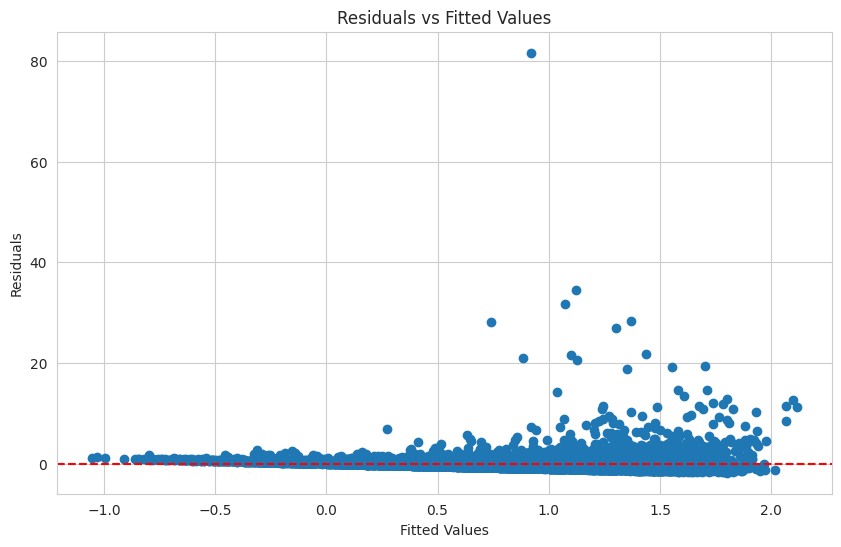

In [13]:
# 1. Check for Homoscedasticity
plt.figure(figsize=(10, 6))
plt.scatter(final_model.fittedvalues, final_model.resid)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

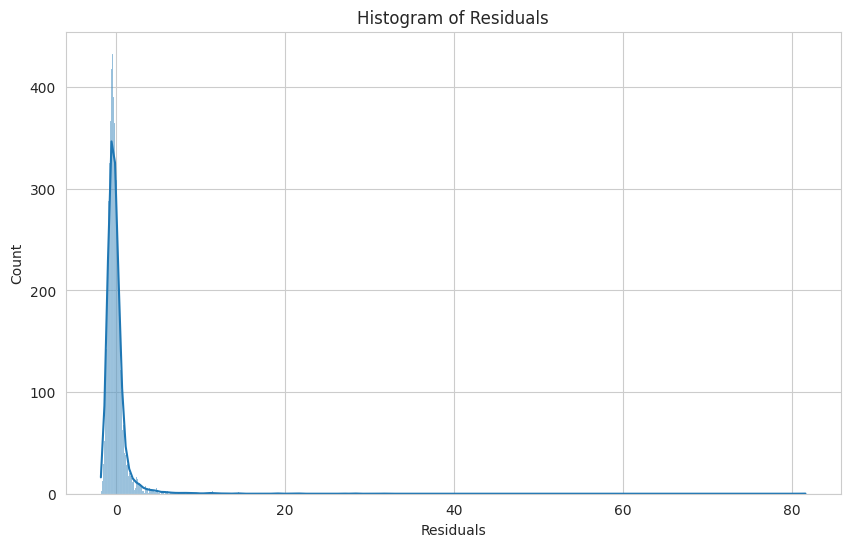

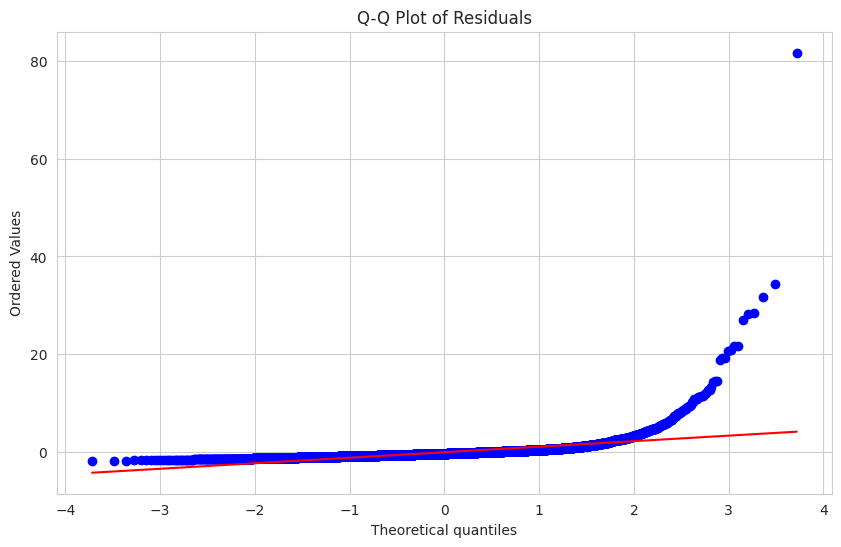

In [14]:
# 2. Check for Normality of Residuals
plt.figure(figsize=(10, 6))
sns.histplot(final_model.resid, kde=True)
plt.xlabel('Residuals')
plt.title('Histogram of Residuals')
plt.show()

# Q-Q plot
plt.figure(figsize=(10, 6))
probplot(final_model.resid, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

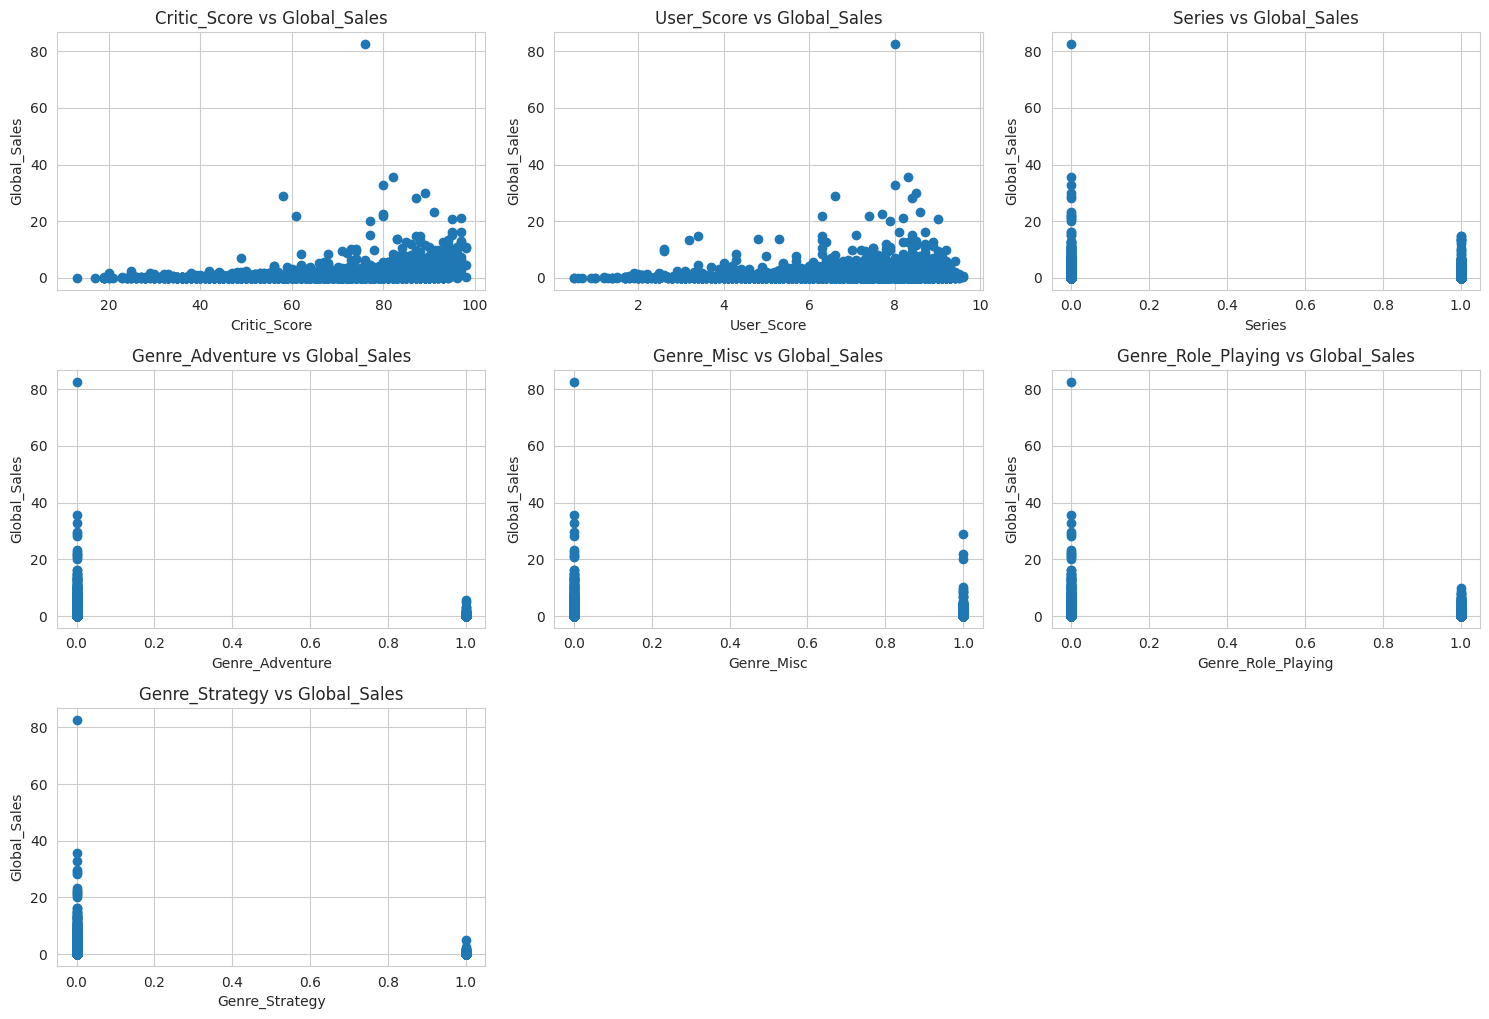

In [15]:
# 3. Check for Linearity
# Scatter plot for each predictor against the outcome
predictors = ['Critic_Score', 'User_Score', 'Series'] + \
             [col for col in games_encoded.columns if col.startswith('Genre_') and col != 'Genre_Sports' and col != 'Genre_Puzzle' and col != 'Genre_Simulation' and col != 'Genre_Fighting' and col != 'Genre_Racing' and col != 'Genre_Shooter' and col != 'Genre_Platform']

plt.figure(figsize=(15, 20))
for i, predictor in enumerate(predictors, 1):
    plt.subplot(6, 3, i)
    plt.scatter(games_encoded[predictor], games_encoded['Global_Sales'])
    plt.xlabel(predictor)
    plt.ylabel('Global_Sales')
    plt.title(f'{predictor} vs Global_Sales')
plt.tight_layout()
plt.show()


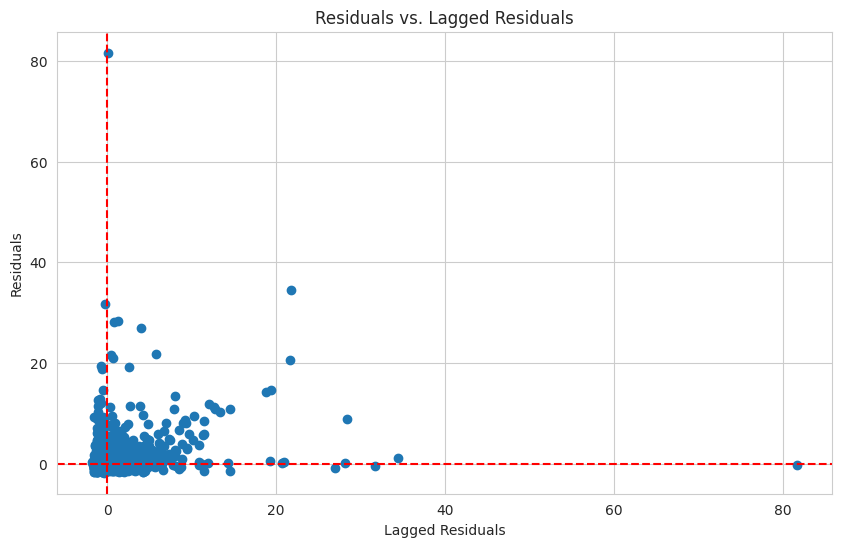

In [16]:
# 4. Check for Independence of Residuals
# Plot residuals vs. lagged residuals
plt.figure(figsize=(10, 6))
plt.scatter(final_model.resid[:-1], final_model.resid[1:])
plt.xlabel('Lagged Residuals')
plt.ylabel('Residuals')
plt.title('Residuals vs. Lagged Residuals')
plt.axhline(0, color='r', linestyle='--')
plt.axvline(0, color='r', linestyle='--')
plt.show()

The scatter plot of Predicted vs. Absolute Residuals shows that the variability of the residuals is nearly constant. Both the QQ-plot and the histogram of the residuals show that they are distributed normally as they follow the line of the QQ-plot and its distribution is bell shaped but right-skewed. The residuals are independent. The rest of the scatter plots suggests that there is a linear relationship between the outcome and each predictor. As all assumptions are not violated, the fitted model does not require any further improvements such as variable transformation or seeking out additional variables to fill model gaps.

##Results
The results of this study showed that many factors have a significant impact on global video game sales. In this article, we have built a multiple linear regression model to determine how criteria such as user and critic ratings, the genre of the game, whether the game is part of a series, as well as attention to the plot and gameplay are related to global game sales.
The multiple linear regression model showed the following key results:\
y^ = β0 ​+ β1​×Genre_Adventure[T.True] + β2​×Genre_Misc[T.True]+ β3​×Genre_Role_Playing[T.True] + β4​×Genre_Strategy[T.True] + β5​×Critic_Score

where:

  β0​ (Intercept) = -1.2665\
  β1​ (Genre_Adventure[T.True]) = -0.3435\
  β2​ (Genre_Misc[T.True]) = 0.3835\
  β3​ (Genre_Role_Playing[T.True]) = -0.1985\
  β4​ (Genre_Strategy[T.True]) = -0.6227\
  β5​ (Critic_Score) = 0.0381

Influencing factors:
critical evaluation (Critic_Score) and belonging to the series have a significant positive impact on global game sales
user ratings (User_Score) have a negative impact on sales.
These results confirm the hypothesis about the impact of evaluation and serialization on the success of the game.

R-square:
The value of the R-square (R^2) is 0.071, which means that about 7.1% of the change in global sales is due to the variables used. This reflects the limited ability of the model to explain all the variability of the data, indicating the importance of other factors in addition to the factors considered.

With the exception of the Critic_Score and Series indicators, other variables such as Story_Focus and Gameplay_Focus do not have a statistically significant impact on global sales. This shows that, at least in the context of this model, focusing on the plot and gameplay is not a decisive factor for selling the game on the global market.

Graphical visualization of data, such as histograms of the distribution of global sales, diagrams of the dependence of global sales on the ratings of critics and users, as well as histograms of average global sales by genre, complement the analysis by providing a visual representation of the relationships between variables.


Thus, our research has confirmed that critical acclaim and a series of games have a significant impact on the commercial success of the game, but user ratings have a significant impact on the commercial success of the game.

##Conclusion
Using the constructed model, which is given in the "Results" section, we can answer the research question: which of the predictors (critic's assessment, user assessment, game focus, series, genre) affect further global sales, and also to what extent?
According to the model, critics' ratings and series strongly and positively correlate with sales. At the same time, user ratings correlate significantly, but negatively. It is noteworthy that, unlike the expectations of the researchers outlined in the introduction, there was no evidence that the genre has an impact on its sales, as well as what the focus of this game is.
Now this data can be used in different conditions to calculate the level of global sales of games and this will make the gaming industry even better.
###Limitations
During the execution of this study, certain limitations were identified that must be taken into account for the correct interpretation of the results:

The study is based on data collected in 2016. Consequently, the latest trends and changes in the gaming industry after this period could remain unnoticed, which may reduce the applicability of the model in modern conditions. In the future, it is advisable to re-analyze from the very beginning, starting with data collection.

The low value of the R2 determination coefficient of the model (approximately 0.071) indicates that the proportion of variability in global video game sales explained by the model is insignificant. This indicates that there are many other factors that are not taken into account in the model and can have a significant impact on global video game sales.

##References
[The final data set (from kaggle.com)](https://www.kaggle.com/datasets/thedevastator/global-video-game-sales-ratings
)

[The original data set (by Timo Potanen)](https://zenodo.org/records/2454579#.Y9Y2c9JBwUE
)